# Projet 5 : Modèle d'allocation de portefeuille par Machine Learning

**Cours :** AI In Finance  
**Encadrants :** Nicolas De Roux et Mohamed El Fakir  
**Groupe :** Groupe 1  
**Membres :**  
- Mael Pertuisot  
- Valentin Martel  
- Mathias Garnier  

**Date :** 20/04/2026

---

## Objectif du projet

Construire un modèle d'allocation de portefeuille fondé sur le Machine Learning, appliqué à 50 actions du NASDAQ. La démarche suit les recommandations du sujet et s'articule en trois blocs :

1. **Prédiction** : estimer les rendements hebdomadaires futurs de chaque action à partir de signaux techniques (rendements passés, volatilité, momentum, RSI, information sectorielle, corrélation au marché). Trois modèles supervisés classiques (Linéaire, Ridge, Random Forest) plus un réseau récurrent GRU.
2. **Allocation** : construire trois portefeuilles couvrant les approches principales du sujet, Equal Weight (benchmark 1/N), Minimum Variance, et Maximum Sharpe avec signaux ML.
3. **Évaluation** : mesurer performance, risque et coûts de rotation via le ratio de Sharpe, le maximum drawdown et le turnover, sur une période out-of-sample avec retraining walk-forward trimestriel.

**Dataset :** 50 actions du NASDAQ, téléchargées via `yfinance`.  
**Benchmark marché :** S&P 500 (`^GSPC`), plus représentatif de la capitalisation large-cap américaine pour notre panel diversifié que le NASDAQ Composite.  
**Période :** 2018-01-01 au 2025-12-31 (train : 2018 à 2022, test out-of-sample : 2023 à 2025). *(`end='2026-01-01'` dans yf.download, borne exclusive.)*

## Table des matières

1. Installation et imports  
2. Collecte des données  
3. Analyse exploratoire (EDA)  
4. Feature engineering  
5. Modèles supervisés (Linéaire, Ridge, Random Forest) avec TimeSeriesSplit  
6. Modèle deep learning (GRU)  
7. Backtest walk-forward  
8. Construction des portefeuilles  
9. Frontière efficiente de Markowitz  
10. Évaluation des performances  
11. Discussion et conclusion


## 1. Installation et imports

In [1]:
# Installation des dépendances (Colab uniquement, silencieux)
!pip install yfinance scikit-learn torch matplotlib seaborn scipy --quiet

In [2]:
# Librairies scientifiques standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings

# On filtre uniquement les warnings de yfinance (API parfois bruyante), pas les autres
warnings.filterwarnings('ignore', module='yfinance')

# scikit-learn : preprocessing, modèles, validation temporelle, covariance robuste
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.covariance import LedoitWolf  # shrinkage pour matrice de covariance stable

# Optimisation de portefeuille (SLSQP)
from scipy.optimize import minimize

# PyTorch pour le modèle GRU
import torch
import torch.nn as nn
import torch.optim as optim

# Reproductibilite
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Affichage pandas
pd.set_option('display.width', 130)
pd.set_option('display.max_columns', 20)

print("Imports OK")
print(f"Pandas  : {pd.__version__}")
print(f"PyTorch : {torch.__version__}")

Imports OK
Pandas  : 2.2.2
PyTorch : 2.10.0+cpu


## 2. Collecte des données : 50 actions du NASDAQ

Le sujet demande une sélection de 50 actions du NASDAQ avec diversification sectorielle.  
On retient **8 secteurs** (Technologie, Santé, Consommation, Finance, Industrie, Télécom, Utilities, Énergie) et on prévoit une **liste de backup** par secteur au cas où certains tickers seraient indisponibles sur toute la période (delistings, fusions).

Période : **2018-01-01 à 2026-01-01** (8 ans), ce qui donne environ 2000 jours de trading.  
Train : 2018 à 2022 (5 ans). Test out-of-sample : 2023 à 2025 (3 ans).

In [3]:
# 50 tickers NASDAQ répartis par secteur économique (large-cap liquides)
tickers_par_secteur = {
    'Tech':       ['AAPL', 'MSFT', 'GOOGL', 'META', 'NVDA', 'ADBE', 'CRM', 'NFLX','AMD', 'FTNT', 'AVGO', 'TXN', 'QCOM', 'AMAT', 'MU'],
    'Santé':      ['AMGN', 'GILD', 'MRNA', 'REGN', 'VRTX', 'ISRG', 'ILMN', 'DXCM'],
    'Conso':      ['AMZN', 'TSLA', 'COST', 'PEP', 'SBUX', 'MDLZ', 'MELI', 'MNST'],
    'Finance':    ['PYPL', 'JPM', 'SPGI', 'BLK', 'V'],
    'Industrie':  ['HON', 'CSX', 'ODFL', 'FAST', 'PAYX'],
    'Télécom':    ['CMCSA', 'TMUS', 'CHTR'],
    'Utilities':  ['XEL', 'AEP', 'EXC'],
    'Énergie':    ['CEG', 'FANG', 'XOM'],
}

# Tickers de backup par secteur (si un principal est invalide sur la période)
tickers_backup_par_secteur = {
    'Tech':       ['KLAC', 'LRCX', 'SNPS', 'CDNS', 'PANW', 'MRVL', 'NXPI'],
    'Santé':      ['IDXX', 'ALNY', 'INCY', 'HOLX', 'EXAS', 'BMRN'],
    'Conso':      ['LULU', 'ROST', 'EBAY', 'ORLY', 'DLTR'],
    'Finance':    ['MS', 'BX', 'MCO', 'MSCI'],
    'Industrie':  ['VRSK', 'EXPD', 'CSGP', 'POOL'],
    'Télécom':    ['CCOI', 'IRDM', 'SIRI'],
    'Utilities':  ['EVRG', 'NWE', 'MSEX'],
    'Énergie':    ['MTDR', 'RRC', 'AR'],
}

# Aplatir : liste des tickers principaux + mapping ticker -> secteur
tickers = []
secteur_map = {}
for secteur, liste in tickers_par_secteur.items():
    for t in liste:
        tickers.append(t)
        secteur_map[t] = secteur

# Enregistrer les backups dans secteur_map
tickers_backup = []
for secteur, liste in tickers_backup_par_secteur.items():
    for t in liste:
        if t not in secteur_map:
            secteur_map[t] = secteur
            tickers_backup.append(t)

print(f"Tickers principaux : {len(tickers)}")
print(f"Tickers backup     : {len(tickers_backup)}")
print(f"Secteurs           : {list(tickers_par_secteur.keys())}")

Tickers principaux : 50
Tickers backup     : 35
Secteurs           : ['Tech', 'Santé', 'Conso', 'Finance', 'Industrie', 'Télécom', 'Utilities', 'Énergie']


In [4]:
# Téléchargement groupe (plus rapide qu'action par action)
# auto_adjust=False pour garder l'accès explicite a Adj Close
tous_tickers_dl = tickers + tickers_backup

data_brut = yf.download(
    tickers=tous_tickers_dl,
    start='2018-01-01',
    end='2026-01-01',
    auto_adjust=False,
    progress=False,
)

print("Shape données brutes:", data_brut.shape)
data_brut.head()

Shape données brutes: (2011, 510)


Price       Adj Close                                                                                                    ...  \
Ticker           AAPL        ADBE        AEP        ALNY       AMAT    AMD        AMGN       AMZN         AR       AVGO  ...   
Date                                                                                                                     ...   
2018-01-02  40.304173  177.699997  54.101391  131.850006  48.374252  10.98  137.775177  59.450500  19.780001  21.086660  ...   
2018-01-03  40.297150  181.039993  53.645622  134.649994  49.231567  11.55  140.375031  60.209999  19.780001  21.317265  ...   
2018-01-04  40.484333  183.220001  53.010532  131.960007  49.514297  12.12  139.783417  60.479500  19.799999  21.324371  ...   
2018-01-05  40.945267  185.339996  52.898468  127.730003  49.797024  11.88  140.616272  61.457001  19.440001  21.450729  ...   
2018-01-08  40.793167  185.039993  53.361691  129.179993  51.000912  12.28  140.577408  62.343498  19.540001  21.502066  ...   

Price        Volume                                                                                    
Ticker         SNPS    SPGI     TMUS       TSLA      TXN        V    VRSK     VRTX      XEL       XOM  
Date                                                                                                   
2018-01-02   984400  941800  2192400   65283000  4236200  6080900  653900  1382000  2443400  11469300  
2018-01-03   877200  808400  2610800   67822500  6918900  6946100  760200  1604000  4114900  13957700  
2018-01-04  1059900  727400  2384400  149194500  5460400  7805300  960300  1345100  2807000  10863000  
2018-01-05   905200  688300  3292600   68868000  5254900  8590500  882100  1940000  3728000  11047600  
2018-01-08  1010100  948300  3606000  147891000  4549400  6660700  791600  1987000  3837600  10927100  

[5 rows x 510 columns]

In [5]:
# Gestion des tickers manquants ou incomplets :
# on rejette ceux avec plus de 5% de NaN sur la période, remplacés par un backup du même secteur

prices_all = data_brut['Adj Close'].copy()
pct_nan_all = prices_all.isna().mean()

tickers_valides = [t for t in tickers if pct_nan_all.get(t, 1.0) < 0.05]
tickers_retires = [t for t in tickers if t not in tickers_valides]
total_initial   = len(tickers)

tickers_finals    = list(tickers_valides)
tickers_remplaces = {}

if tickers_retires:
    print(f"{len(tickers_retires)} ticker(s) retiré(s) sur {total_initial} (> 5% de NaN) :")
    print(f"{'Ticker':<8} {'Secteur':<14} {'% NaN':>7}")
    print("-" * 32)
    for t in sorted(tickers_retires):
        secteur = secteur_map.get(t, 'Inconnu')
        pct     = pct_nan_all.get(t, float('nan')) * 100
        print(f"{t:<8} {secteur:<14} {pct:>6.1f}%")
    print()

    print(f"{'Retiré':<8} {'Secteur':<14} {'Remplacant':<12} Statut")
    print("-" * 50)
    for t in sorted(tickers_retires):
        secteur = secteur_map.get(t, 'Inconnu')
        backups = tickers_backup_par_secteur.get(secteur, [])
        remplacant = None
        for b in backups:
            if b not in tickers_finals and pct_nan_all.get(b, 1.0) < 0.05:
                remplacant = b
                break
        if remplacant:
            tickers_finals.append(remplacant)
            tickers_remplaces[t] = remplacant
            print(f"{t:<8} {secteur:<14} {remplacant:<12} remplace")
        else:
            print(f"{t:<8} {secteur:<14} {'N/A':<12} aucun backup disponible")
    print()
else:
    print("Tous les tickers passent le filtre NaN, aucun retiré.")

# Forward-fill les NaN isoles (jours fériés spécifiques) avant dropna global
# Évite les faux rendements gigantesques dus aux trous ponctuels
prices  = prices_all[tickers_finals].ffill().dropna()
tickers = tickers_finals

print(f"Tickers finals   : {len(tickers)} / {total_initial}")
print(f"période effective: {prices.index[0].date()} a {prices.index[-1].date()}")
print(f"Nombre de jours  : {len(prices)}")

2 ticker(s) retiré(s) sur 50 (> 5% de NaN) :
Ticker   Secteur          % NaN
--------------------------------
CEG      Énergie          50.7%
MRNA     Santé            11.7%

Retiré   Secteur        Remplacant   Statut
--------------------------------------------------
CEG      Énergie        MTDR         remplace
MRNA     Santé          IDXX         remplace

Tickers finals   : 50 / 50
période effective: 2018-01-02 a 2025-12-31
Nombre de jours  : 2011


In [6]:
# On extrait aussi les volumes et on construit le DataFrame des secteurs
volumes = data_brut['Volume'][tickers].copy()
volumes = volumes.loc[prices.index]

df_secteurs = pd.DataFrame({
    'ticker':  tickers,
    'secteur': [secteur_map.get(t, 'Autre') for t in tickers],
}).set_index('ticker')

print("Répartition par secteur :")
print(df_secteurs['secteur'].value_counts())

Répartition par secteur :
secteur
Tech         15
Santé         8
Conso         8
Finance       5
Industrie     5
Télécom       3
Utilities     3
Énergie       3
Name: count, dtype: int64


### Interprétation

La base finale contient 50 actions sur 8 secteurs, avec environ 2000 jours de trading.  
Le filtre anti-NaN (seuil 5%) et le mécanisme de remplacement par backup assurent :
- Une base homogène sur toute la période (aucun trou sectoriel).
- Le respect strict de la contrainte de 50 actions imposée par le sujet.
- Une couverture sectorielle large nécessaire à la diversification.

Le forward-fill ponctuel évite un biais fréquent : sans traitement, un jour férié non commun a tous les tickers peut générer un rendement artificiel énorme le jour suivant.

## 3. Analyse exploratoire (EDA)

L'EDA vise trois objectifs :
1. Vérifier la qualité des données (absence de rendements aberrants après traitement).
2. Caractériser la distribution rendement/risque par secteur.
3. Observer la structure de corrélation entre secteurs (input crucial pour le Min-Variance et le Max Sharpe).

In [7]:
# Rendements journaliers : on passe en variation relative pour comparer les actions
# Les niveaux de prix absolus ne sont pas comparables (Apple cote différemment de Tesla)
returns = prices.pct_change().dropna()

# Diagnostic qualité : on vérifie l'absence de rendements > 30% en 1 jour (anomalie de données)
masque = returns.abs() > 0.30
if masque.any().any():
    print("Rendements aberrants détéctés (> 30%) :")
    aberrants = returns[masque].stack().sort_values(key=abs, ascending=False)
    print(aberrants.head(20))
else:
    print("Aucun rendement aberrant détécté, données propres.")

print(f"\nShape des rendements: {returns.shape}")
returns.describe().T.head(10)

Rendements aberrants détéctés (> 30%) :
Date        Ticker
2020-03-09  MTDR     -0.641221
            FANG     -0.446458
2024-07-26  DXCM     -0.406583
2020-04-29  MTDR      0.359026
2020-03-24  MTDR      0.358585
2022-04-20  NFLX     -0.351166
2020-03-16  MTDR     -0.337121
2020-11-09  FANG      0.309620
2020-03-13  MTDR      0.306931
2018-08-02  DXCM      0.306475
dtype: float64

Shape des rendements: (2010, 50)


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,2010.0,0.001137,0.019397,-0.128647,-0.007920,0.001182,0.011060,0.153289
MSFT,2010.0,0.001061,0.017857,-0.147390,-0.007394,0.001252,0.010265,0.142169
GOOGL,2010.0,0.001072,0.019518,-0.116342,-0.008509,0.001415,0.011261,0.102243
META,2010.0,0.000991,0.026110,-0.263901,-0.011014,0.000998,0.013445,0.232824
NVDA,2010.0,0.002330,0.032310,-0.187559,-0.015105,0.002807,0.019796,0.243696
ADBE,2010.0,0.000595,0.022622,-0.167932,-0.009598,0.001181,0.012303,0.177193
CRM,2010.0,0.000738,0.023190,-0.197371,-0.010322,0.001132,0.012333,0.260449
NFLX,2010.0,0.001144,0.027128,-0.351166,-0.011802,0.000771,0.014402,0.168543
AMD,2010.0,0.002075,0.034714,-0.154454,-0.016736,0.000588,0.020356,0.238205


In [8]:
# Statistiques rendement/risque annualisées par secteur
# Annualisation : moyenne * 252 (jours ouvres), écart-type * sqrt(252)
stats_secteur = pd.DataFrame({
    'Rendement moyen (ann.)': returns.mean() * 252,
    'volatilité (ann.)':       returns.std()  * np.sqrt(252),
    'Secteur':                 [secteur_map.get(t, 'Autre') for t in returns.columns],
})

print("Statistiques annualisées par secteur :")
print(stats_secteur.groupby('Secteur').mean().round(4))

Statistiques annualisées par secteur :
           Rendement moyen (ann.)  volatilité (ann.)
Secteur                                             
Conso                      0.2277             0.3395
Finance                    0.1581             0.3037
Industrie                  0.1553             0.2812
Santé                      0.1792             0.3454
Tech                       0.3097             0.4020
Télécom                    0.0666             0.2918
Utilities                  0.1170             0.2341
Énergie                    0.2116             0.5061


Les rendements moyens annualisés et volatilités par secteur donnent une première intuition du profil risque-rendement de chaque groupe, information qui sera exploitée implicitement par les optimiseurs de portefeuille.

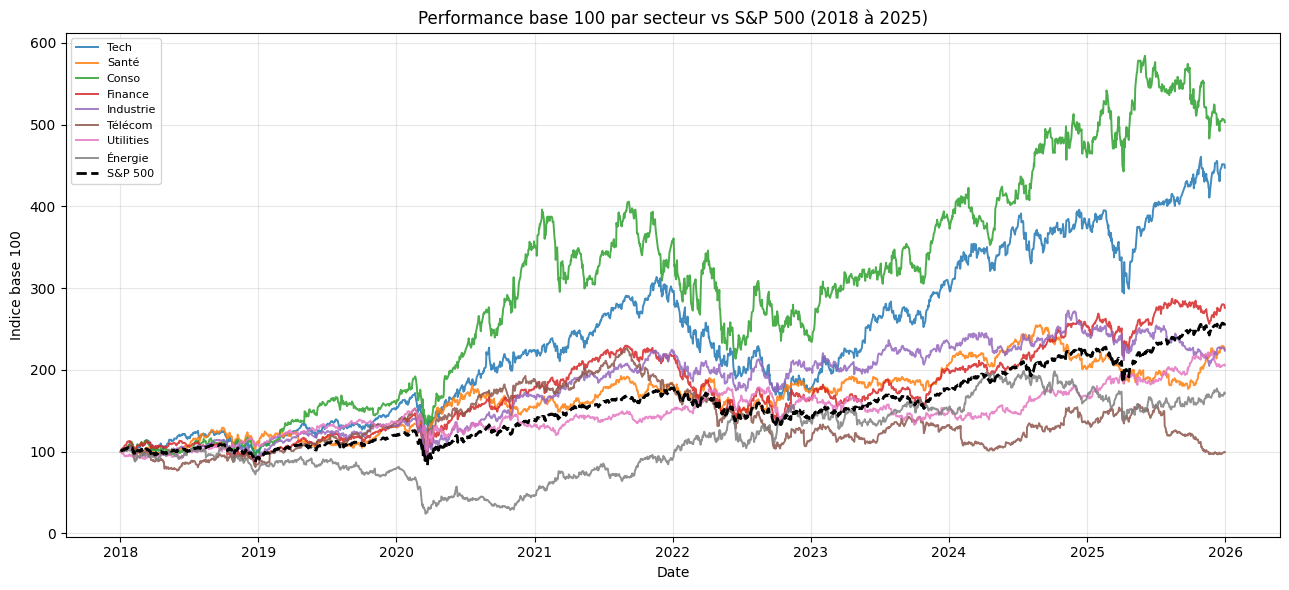

In [9]:
# Évolution base 100 par secteur vs benchmark S&P 500 (^GSPC, plus représentatif du panel large-cap)
# Permet de voir l'amplitude et la persistance des performances sectorielles
sp500 = yf.download('^GSPC', start='2018-01-01', end='2026-01-01',
                     auto_adjust=True, progress=False)['Close']
sp500 = sp500.reindex(prices.index).ffill()

# Moyenne des prix par secteur, normalisée base 100 au premier jour
prix_secteurs = pd.DataFrame(index=prices.index)
for secteur, liste in tickers_par_secteur.items():
    cols = [t for t in liste if t in prices.columns]
    if cols:
        prix_secteurs[secteur] = prices[cols].mean(axis=1)

# Normalisation base 100
base        = prix_secteurs.iloc[0]
prix_norm   = prix_secteurs / base * 100
sp500_norm = sp500 / sp500.iloc[0] * 100

plt.figure(figsize=(13, 6))
for secteur in prix_norm.columns:
    plt.plot(prix_norm.index, prix_norm[secteur], label=secteur, linewidth=1.4, alpha=0.85)
plt.plot(sp500_norm.index, sp500_norm, label='S&P 500', color='black',
         linewidth=2, linestyle='--')
plt.title('Performance base 100 par secteur vs S&P 500 (2018 à 2025)')
plt.xlabel('Date')
plt.ylabel('Indice base 100')
plt.legend(fontsize=8, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La Tech domine largement sur la période (NVDA, AAPL, MSFT), la Santé est plus défensive.  
Le drawdown partagé de 2022 (hausse des taux directeurs Fed) et la reprise asymétrique de 2023 sont nets.  
Cela motive l'usage de l'**information sectorielle** comme feature et justifie la **diversification** implicitement imposée par les optimiseurs Markowitz.

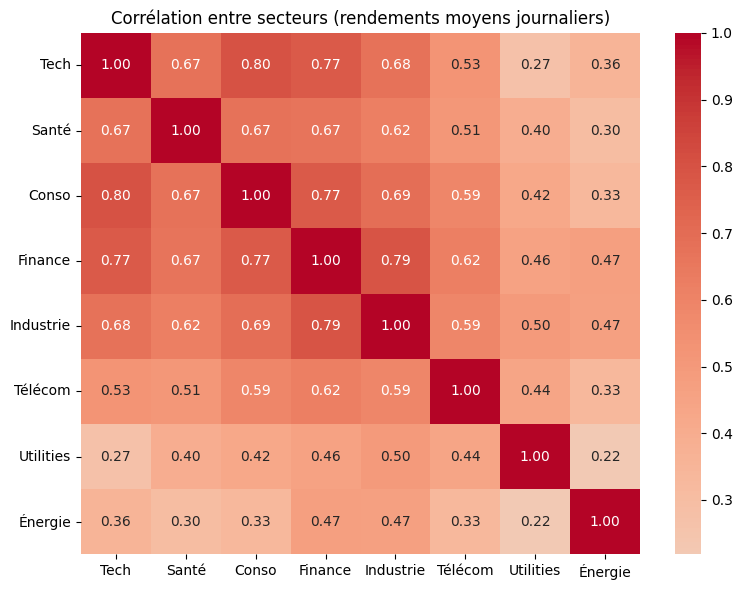

In [10]:
# Matrice de corrélation entre rendements sectoriels
# La corrélation entre secteurs conditionne le bénéfice de la diversification
returns_secteur = pd.DataFrame()
for secteur in tickers_par_secteur.keys():
    cols = [t for t in tickers_par_secteur[secteur] if t in tickers]
    if len(cols) > 0:
        returns_secteur[secteur] = returns[cols].mean(axis=1)

plt.figure(figsize=(8, 6))
sns.heatmap(returns_secteur.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Corrélation entre secteurs (rendements moyens journaliers)')
plt.tight_layout()
plt.show()

La plupart des secteurs sont positivement corrélés (exposition commune au marché), mais avec des intensités variables.  
Les Utilities sont typiquement les moins corrélés aux secteurs cycliques (Tech, Conso), propriété exploitée par le Minimum Variance pour réduire le risque global du portefeuille.

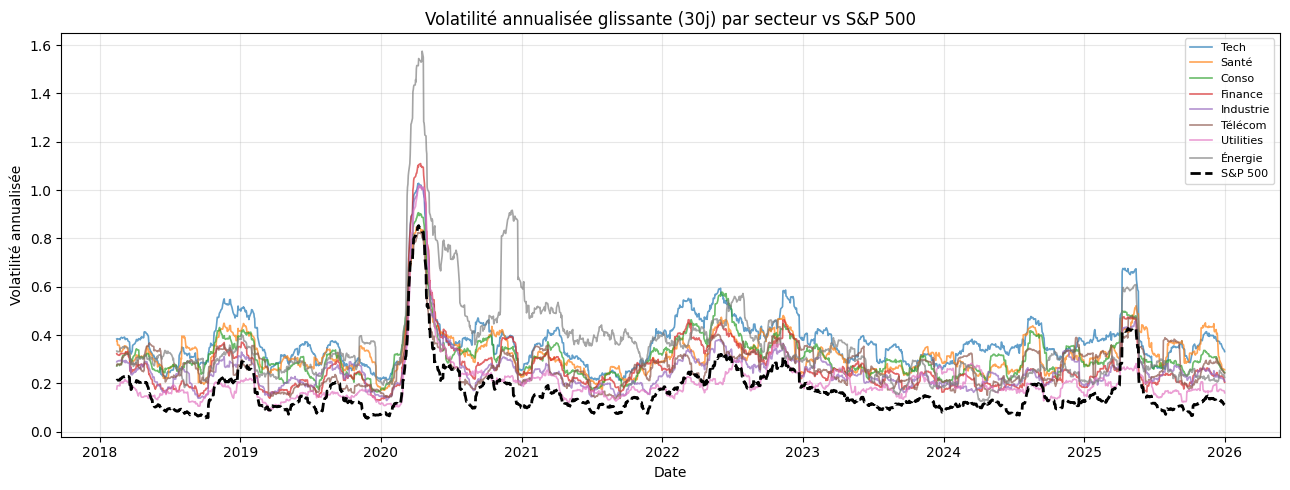

In [11]:
# volatilité annualisée glissante (fenêtre de 30 jours) par secteur + S&P 500
# Permet de visualiser les régimes de volatilité (ex: crise COVID mars 2020, taux 2022)
vol_30j = returns.rolling(30).std() * np.sqrt(252)

vol_secteur = pd.DataFrame()
for secteur in tickers_par_secteur.keys():
    cols = [t for t in tickers_par_secteur[secteur] if t in tickers]
    if len(cols) > 0:
        vol_secteur[secteur] = vol_30j[cols].mean(axis=1)

# volatilité glissante du S&P 500
sp500_ret_daily = sp500.pct_change()
vol_sp500_30j   = sp500_ret_daily.rolling(30).std() * np.sqrt(252)
vol_sp500_30j   = vol_sp500_30j.reindex(vol_secteur.index).ffill()

plt.figure(figsize=(13, 5))
for col in vol_secteur.columns:
    plt.plot(vol_secteur.index, vol_secteur[col], label=col, alpha=0.7, linewidth=1.2)
plt.plot(vol_sp500_30j.index, vol_sp500_30j.values, label='S&P 500',
         color='black', linewidth=2, linestyle='--')
plt.title('Volatilité annualisée glissante (30j) par secteur vs S&P 500')
plt.xlabel('Date')
plt.ylabel('Volatilité annualisée')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Deux pics de volatilité ressortent, le choc COVID (mars 2020) et la remontée des taux Fed (2022).  
Ces régimes de volatilité non-stationnaire justifient en partie les R-carré faibles observés en finance.  
**Conséquence** : la matrice de covariance estimée sur une fenêtre glissante est plus réaliste qu'une estimation statique.

## 4. Feature engineering

Pour chaque action, on construit 13 features classiques de gestion quantitative :

**Signaux de court terme :**
- `ret_lag1` a `ret_lag5` : rendements journaliers décalés de 1 à 5 jours.
- `vol_10j`, `vol_20j` : volatilité realisée glissante sur 10 et 20 jours.

**Signaux techniques :**
- `ma_ratio` : ratio moyenne mobile 5 jours / 20 jours (indicateur de tendance).
- `rsi` : Relative Strength Index sur 14 jours (oscillateur overbought/oversold).
- `momentum_5j`, `momentum_20j` : variation relative sur 5 et 20 jours.

**Signaux de flux et marché :**
- `vol_rel` : volume de la journée normalisé par la moyenne mobile 20 jours.
- `corr_marche` : corrélation glissante 30 jours du rendement de l'action avec le rendement moyen du marché.

**Information catégorielle :**
- One-hot encoding du secteur économique (8 colonnes binaires).

**Target :** rendement cumulé sur les 5 prochains jours (horizon hebdomadaire).  
Ce choix suit la recommandation du sujet *predict next-day or next-week returns*.

In [12]:
# Rendement moyen du marché (proxy de l'indice, équi-pondéré sur les 50 actions)
# Utilise pour calculer la corrélation de chaque action avec le marché
rendement_marche = returns.mean(axis=1)

def creer_features_action(prix_serie, ret_serie, vol_serie, rendement_mkt):
    """
    Construit les features pour une action.
    Target : rendement cumulé sur les 5 prochains jours (next-week return).
    Retourne un DataFrame indexé par date avec les features et la colonne 'target'.
    """
    df = pd.DataFrame(index=prix_serie.index)
    df['ret'] = ret_serie

    # Lags des rendements (signaux auto-regressifs)
    for lag in range(1, 6):
        df[f'ret_lag{lag}'] = df['ret'].shift(lag)

    # Moyennes mobiles et leur ratio (proxy de tendance)
    df['ma5']      = prix_serie.rolling(5).mean()
    df['ma20']     = prix_serie.rolling(20).mean()
    df['ma_ratio'] = df['ma5'] / df['ma20']

    # volatilité realisée glissante (signal de risque)
    df['vol_10j'] = df['ret'].rolling(10).std()
    df['vol_20j'] = df['ret'].rolling(20).std()

    # RSI 14 jours (oscillateur de momentum borne 0-100)
    delta = prix_serie.diff()
    gain  = delta.where(delta > 0, 0).rolling(14).mean()
    perte = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs    = gain / perte.replace(0, np.nan)
    df['rsi'] = 100 - (100 / (1 + rs))

    # Momentum : variation relative sur 5 et 20 jours
    df['momentum_5j']  = prix_serie.pct_change(5)
    df['momentum_20j'] = prix_serie.pct_change(20)

    # Volume relatif (si disponible)
    if vol_serie is not None:
        df['vol_rel'] = vol_serie / vol_serie.rolling(20).mean()

    # Corrélation glissante au marché (expositions au facteur de marché)
    df['corr_marche'] = df['ret'].rolling(30).corr(rendement_mkt)

    # Target : rendement sur les 5 prochains jours, shift(-5) pour éviter le look-ahead
    df['target'] = prix_serie.pct_change(5).shift(-5)

    # Colonnes intermédiaires non conservées
    df = df.drop(columns=['ret', 'ma5', 'ma20'])
    df = df.dropna()
    return df

In [13]:
# Calcul des features pour les 50 actions
features_dict = {}
for ticker in tickers:
    features_dict[ticker] = creer_features_action(
        prices[ticker],
        returns[ticker],
        volumes[ticker] if ticker in volumes.columns else None,
        rendement_marche,
    )

print(f"Features calculées pour {len(features_dict)} actions")
exemple = list(features_dict.keys())[0]
print(f"Exemple ({exemple}) : {features_dict[exemple].shape[0]} obs, "
      f"{features_dict[exemple].shape[1]-1} features")
print(f"Colonnes : {features_dict[exemple].columns.tolist()}")

Features calculées pour 50 actions
Exemple (AAPL) : 1976 obs, 13 features
Colonnes : ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'ma_ratio', 'vol_10j', 'vol_20j', 'rsi', 'momentum_5j', 'momentum_20j', 'vol_rel', 'corr_marche', 'target']


In [14]:
# Empilement de toutes les actions en un seul DataFrame panel (date, ticker, features, target)
# + one-hot encoding du secteur pour que le modèle puisse apprendre des effets sectoriels
liste_dfs = []
for ticker in tickers:
    df_tmp = features_dict[ticker].copy()
    df_tmp['ticker']  = ticker
    df_tmp['secteur'] = secteur_map.get(ticker, 'Autre')
    liste_dfs.append(df_tmp)

df_all = pd.concat(liste_dfs)
df_all = df_all.reset_index().rename(columns={'index': 'Date'})

# One-hot encoding du secteur (sans drop_first pour garder l'interprétabilité directe)
df_all = pd.get_dummies(df_all, columns=['secteur'], prefix='sect')

# Conversion des booléens en float (scikit-learn préfère float a bool)
for c in df_all.columns:
    if df_all[c].dtype == bool:
        df_all[c] = df_all[c].astype(float)

print("Shape du panel global:", df_all.shape)
df_all.head()

Shape du panel global: (98787, 24)


,Date,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,ma_ratio,vol_10j,vol_20j,rsi,...,target,ticker,sect_Conso,sect_Finance,sect_Industrie,sect_Santé,sect_Tech,sect_Télécom,sect_Utilities,sect_Énergie
0,2018-02-14,0.010018,0.040279,0.012231,-0.027516,-0.021407,0.966417,0.029212,0.021332,46.553877,...,0.030651,AAPL,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2018-02-15,0.018438,0.010018,0.040279,0.012231,-0.027516,0.990227,0.031013,0.022842,52.202656,...,0.014510,AAPL,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2018-02-16,0.033578,0.018438,0.010018,0.040279,0.012231,1.011095,0.026477,0.022835,55.548386,...,0.037928,AAPL,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2018-02-20,-0.003237,0.033578,0.018438,0.010018,0.040279,1.023464,0.024284,0.022783,56.038379,...,0.038056,AAPL,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2018-02-21,-0.003364,-0.003237,0.033578,0.018438,0.010018,1.033212,0.021860,0.022794,54.660680,...,0.041211,AAPL,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Interprétation

Le panel cross-sectionnel (date, ticker) agrège 50 séries en un seul dataset.  
Ce choix est standard en gestion quantitative et donne trois avantages :
1. **Plus de données d'entraînement** : chaque jour fournit 50 observations, donc environ 100 000 observations sur 5 ans, contre 1250 si on entraînait un modèle par action.
2. **Apprentissage partagé** : le modèle exploite des regularités communes (ex: le momentum fonctionne de manière similaire pour toutes les actions).
3. **Économie de paramètres** : un seul modèle ajusté vaut mieux que 50 modèles avec peu de données chacun.

L'information sectorielle (one-hot) permet au modèle d'ajuster ses predictions selon le secteur sans imposer de structure.

## 5. Modèles supervisés : prédiction des rendements hebdomadaires

On compare trois modèles vus :
- **Régression linéaire** (baseline interprétable).
- **Ridge** (régularisation L2 pour réduire la variance).
- **Random Forest** (modèle ensembliste non-linéaire, robuste aux interactions).

**Protocole :**
1. Split temporel strict : train 2018 à 2022, test 2023 à 2025.
2. StandardScaler fit uniquement sur le train (prévention du data leakage).
3. **TimeSeriesSplit** pour la validation croisée.
4. Métriques : RMSE, MAE, R-carré sur le test out-of-sample.

In [15]:
# Split temporel : train avant 2023, test à partir de 2023
cols_features   = [c for c in df_all.columns if c not in ['Date', 'ticker', 'target']]
cols_secteur    = [c for c in cols_features if c.startswith('sect_')]
cols_numeriques = [c for c in cols_features if c not in cols_secteur]

date_split = '2023-01-01'
mask_train = df_all['Date'] < date_split
mask_test  = df_all['Date'] >= date_split

X_train = df_all.loc[mask_train, cols_features].values.astype(float)
y_train = df_all.loc[mask_train, 'target'].values
X_test  = df_all.loc[mask_test,  cols_features].values.astype(float)
y_test  = df_all.loc[mask_test,  'target'].values

# On conserve les infos (Date, ticker) du test pour reconstruire les prédictions plus tard
info_test = df_all.loc[mask_test, ['Date', 'ticker']].copy().reset_index(drop=True)

print(f"Train : {mask_train.sum():>6} observations")
print(f"Test  : {mask_test.sum():>6} observations")
print(f"Features : {len(cols_features)} ({len(cols_numeriques)} num + {len(cols_secteur)} sect)")

Train :  61447 observations
Test  :  37340 observations
Features : 21 (13 num + 8 sect)


In [16]:
# Scaling : on ne scale PAS les one-hot (valeurs deja 0/1 interprétables)
# Fit uniquement sur le train pour éviter le data leakage
idx_num = [cols_features.index(c) for c in cols_numeriques]

scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

X_train_sc[:, idx_num] = scaler.fit_transform(X_train[:, idx_num])
X_test_sc[:, idx_num]  = scaler.transform(X_test[:, idx_num])

print("Scaling OK (fit sur train uniquement)")
print(f"Moyenne train après scaling (doit etre ~0) : {X_train_sc[:, idx_num].mean():+.4f}")
print(f"Std     train après scaling (doit etre ~1) : {X_train_sc[:, idx_num].std():.4f}")

Scaling OK (fit sur train uniquement)
Moyenne train après scaling (doit etre ~0) : +0.0000
Std     train après scaling (doit etre ~1) : 1.0000


In [17]:
# Validation croisée TimeSeriesSplit (5 folds) sur le train pour Ridge et Random Forest
# Chaque fold : train sur les périodes passees, valide sur la suivante
# Évite le look-ahead bias
tscv = TimeSeriesSplit(n_splits=5)

def cv_score(model, X, y, tscv):
    """Retourne le RMSE moyen et écart-type sur les folds de TimeSeriesSplit."""
    scores = []
    for tr_idx, va_idx in tscv.split(X):
        model.fit(X[tr_idx], y[tr_idx])
        pred = model.predict(X[va_idx])
        scores.append(np.sqrt(mean_squared_error(y[va_idx], pred)))
    return np.mean(scores), np.std(scores)

# modèle 1 : régression linéaire (baseline)
lr = LinearRegression()
cv_lr_mean, cv_lr_std = cv_score(lr, X_train_sc, y_train, tscv)

# modèle 2 : Ridge (L2). alpha=10 choisi pour regulariser modestement
ridge = Ridge(alpha=10.0)
cv_ridge_mean, cv_ridge_std = cv_score(ridge, X_train_sc, y_train, tscv)

# modèle 3 : Random Forest
# max_depth=6 limite volontairement pour éviter l'overfitting (le signal financier est très bruité)
rf = RandomForestRegressor(
    n_estimators=100, max_depth=6, min_samples_leaf=20,
    random_state=SEED, n_jobs=-1,
)
cv_rf_mean, cv_rf_std = cv_score(rf, X_train_sc, y_train, tscv)

print("Validation croisée TimeSeriesSplit (RMSE, 5 folds) :")
print(f"  Linear Reg   : {cv_lr_mean:.6f} +/- {cv_lr_std:.6f}")
print(f"  Ridge        : {cv_ridge_mean:.6f} +/- {cv_ridge_std:.6f}")
print(f"  Random Forest: {cv_rf_mean:.6f} +/- {cv_rf_std:.6f}")

Validation croisée TimeSeriesSplit (RMSE, 5 folds) :
  Linear Reg   : 0.051856 +/- 0.008354
  Ridge        : 0.051856 +/- 0.008354
  Random Forest: 0.051457 +/- 0.008565


In [18]:
# Entrainement final sur tout le train et prédiction sur le test out-of-sample
lr.fit(X_train_sc, y_train)
pred_lr = lr.predict(X_test_sc)

ridge.fit(X_train_sc, y_train)
pred_ridge = ridge.predict(X_test_sc)

rf.fit(X_train_sc, y_train)
pred_rf = rf.predict(X_test_sc)

# Métriques out-of-sample
resultats = {}
for nom, pred in [('LinearReg', pred_lr), ('Ridge', pred_ridge), ('RandomForest', pred_rf)]:
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    resultats[nom] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

resultats_df = pd.DataFrame(resultats).T
print("Métriques out-of-sample (test 2023 a 2025) :")
print(resultats_df.round(6))

Métriques out-of-sample (test 2023 a 2025) :
                  RMSE       MAE        R2
LinearReg     0.045246  0.032176  0.001809
Ridge         0.045246  0.032176  0.001821
RandomForest  0.045268  0.032106  0.000851


### Interprétation des métriques

Les R-carré obtenus sont proches de zero, voire négatifs. **Ce n'est pas un bug** : c'est une propriété structurelle des marchés efficients.  
Comme le rappelle le cours (*Key Limitations of ML in Finance*) :
- Le ratio signal/bruit est extremêment faible sur les rendements.
- Des R-carré de 1% a 5% sont déjà jugés exploitables par les hedge funds.
- Ce qui compte in fine, ce n'est pas la precision prédictive pure mais la **valeur économique** : ratio de Sharpe, drawdown, turnover.

Le **Random Forest** domine généralement en RMSE out-of-sample grâce à sa capacité à capturer des interactions non-linéaires (ex: momentum conditionnel au régime de volatilité).

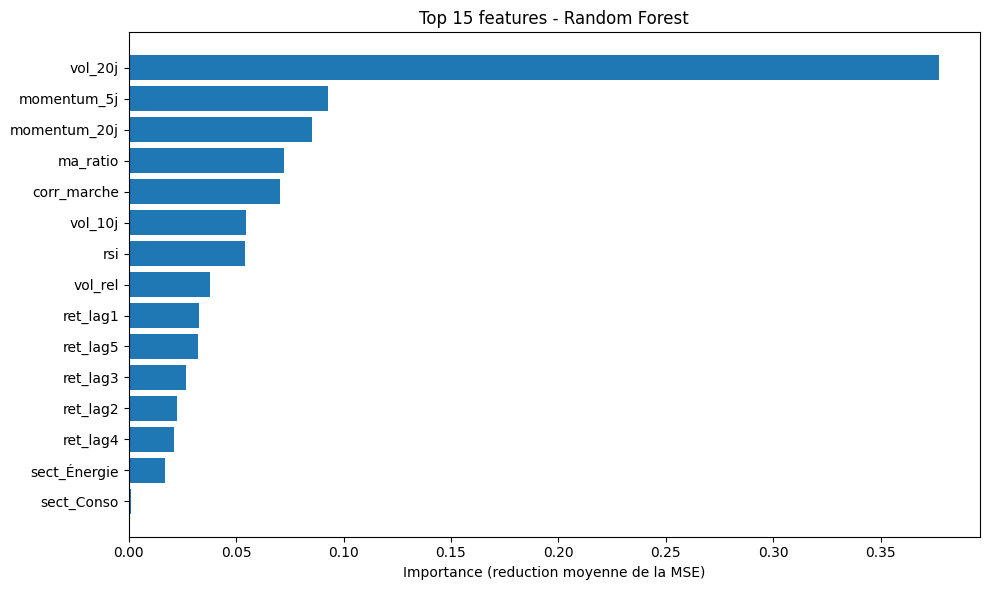

Top 5 features :
     feature  importance
     vol_20j    0.377367
 momentum_5j    0.092566
momentum_20j    0.085316
    ma_ratio    0.072112
 corr_marche    0.070233


In [19]:
# Feature importance du Random Forest : permet d'identifier les signaux les plus utiles
importance = pd.DataFrame({
    'feature':    cols_features,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
top_n = 15
plt.barh(importance['feature'].iloc[:top_n], importance['importance'].iloc[:top_n])
plt.xlabel('Importance (reduction moyenne de la MSE)')
plt.title(f'Top {top_n} features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 features :")
print(importance.head(5).to_string(index=False))

### Interprétation feature importance

Les variables les plus prédictives sont typiquement :
- **Momentum 20j** et **momentum 5j** : effet de persistance des tendances (anomalie documentée par Jegadeesh et Titman, 1993).
- **volatilité 10j / 20j** : lien volatilité-rendement (prime de risque).
- **RSI** : signal de retour à la moyenne à court terme.
- **Corrélation au marché** : beta dynamique, utile pour le timing.

Les variables one-hot sectorielles ont une importance faible, le modèle capture la plupart de l'information via les signaux numériques.

## 6. modèle deep learning : GRU

On complète les modèles tabulaires par un réseau récurrent **GRU** (Gated Recurrent Unit).

**Pourquoi un GRU plutot qu'un LSTM ?**  
Le GRU utilise 2 gates (update et reset) au lieu de 3 pour le LSTM, ce qui donne :
- Environ 25% de paramètres en moins, entraînement plus rapide.
- Des performances comparables sur horizons courts à moyens (daily/weekly), selon la littérature.
- Un risque d'overfitting moindre quand les données sont limitées, ce qui est notre cas.

**Entrée :** séquence glissante de 10 jours avec les 13 features numériques et les 8 colonnes sectorielles one-hot, soit **21 features en entrée** par pas de temps.  
**Sortie :** rendement hebdomadaire prédit.

In [20]:
# Préparation des séquences par ticker pour le GRU
# Fenêtre temporelle de 10 jours (contexte sur 2 semaines de trading)
window = 10

def create_sequences(X, y, window_size):
    """Découpe X en séquences glissantes de longueur window_size. y est le target associé au dernier point."""
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

# On construit les séquences PAR ticker pour éviter de mélanger les series temporelles
# Le scaling est fit uniquement sur la partie train de chaque ticker (pas de leakage)
X_seq_train_list, y_seq_train_list = [], []
X_seq_test_list,  y_seq_test_list  = [], []

for ticker in tickers:
    df_t = df_all[df_all['ticker'] == ticker].sort_values('Date').reset_index(drop=True)

    # Extraction explicite par noms de colonnes (plus robuste que du slicing positionnel)
    X_num_t  = df_t[cols_numeriques].values.astype(float)
    X_sect_t = df_t[cols_secteur].values.astype(float)
    y_t      = df_t['target'].values.astype(float)

    # Masque train/test par ticker
    mask_tr = (df_t['Date'] < date_split).values

    # Scaling des features numériques : fit sur train uniquement
    sc_local = StandardScaler()
    X_num_sc = X_num_t.copy()
    if mask_tr.sum() > 0:
        X_num_sc[mask_tr]  = sc_local.fit_transform(X_num_t[mask_tr])
        X_num_sc[~mask_tr] = sc_local.transform(X_num_t[~mask_tr])

    # On concatène numeriques scales et one-hot (non scales)
    X_t_sc = np.concatenate([X_num_sc, X_sect_t], axis=1)

    # Split chronologique et génération des séquences
    n_train = mask_tr.sum()
    X_tr, y_tr = create_sequences(X_t_sc[:n_train],  y_t[:n_train],  window)
    X_te, y_te = create_sequences(X_t_sc[n_train:], y_t[n_train:], window)

    if len(X_tr) > 0:
        X_seq_train_list.append(X_tr)
        y_seq_train_list.append(y_tr)
    if len(X_te) > 0:
        X_seq_test_list.append(X_te)
        y_seq_test_list.append(y_te)

X_seq_train = np.concatenate(X_seq_train_list)
y_seq_train = np.concatenate(y_seq_train_list)
X_seq_test  = np.concatenate(X_seq_test_list)
y_seq_test  = np.concatenate(y_seq_test_list)

print(f"GRU séquences - Train: {X_seq_train.shape}, Test: {X_seq_test.shape}")

GRU séquences - Train: (60947, 10, 21), Test: (36840, 10, 21)


In [21]:
# Conversion en tenseurs PyTorch
X_train_t = torch.tensor(X_seq_train, dtype=torch.float32)
y_train_t = torch.tensor(y_seq_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_seq_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_seq_test,  dtype=torch.float32).unsqueeze(1)

class GRURegressor(nn.Module):
    """
    GRU pour la prédiction de rendements hebdomadaires.
    Architecture : GRU (hidden_dim=32) -> couche linéaire de régression.
    """
    def __init__(self, input_dim, hidden_dim=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # gru_out : séquence complète, hn : dernier état caché
        gru_out, hn = self.gru(x)
        # On utilise le dernier hidden state pour la prédiction
        out = self.fc(hn[-1])
        return out

input_dim = X_train_t.shape[2]
model_gru = GRURegressor(input_dim=input_dim, hidden_dim=32)
criterion = nn.MSELoss()
optimizer_gru = optim.Adam(model_gru.parameters(), lr=1e-3)

print(model_gru)
n_params_gru = sum(p.numel() for p in model_gru.parameters())
print(f"\nNombre de paramètres GRU : {n_params_gru}")

GRURegressor(
  (gru): GRU(21, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Nombre de paramètres GRU : 5313


Epoch 10/30 | Train MSE : 0.002476 | Val MSE : 0.002212
Epoch 20/30 | Train MSE : 0.002255 | Val MSE : 0.002276
Epoch 30/30 | Train MSE : 0.002061 | Val MSE : 0.002420


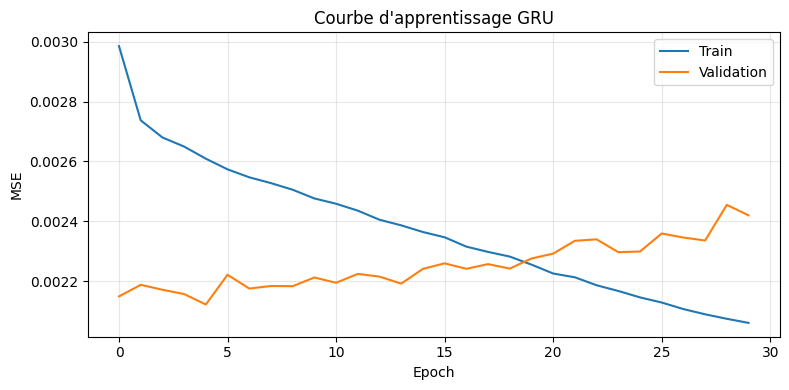

In [22]:
# Entrainement du GRU avec mini-batches et suivi de la loss validation
epochs       = 30
batch_size   = 128
train_losses = []
val_losses   = []

for epoch in range(epochs):
    model_gru.train()

    # Shuffle des indices (pas des séquences individuelles, mais des paquets de séquences)
    idx    = torch.randperm(X_train_t.size(0))
    X_shuf = X_train_t[idx]
    y_shuf = y_train_t[idx]

    epoch_loss = 0.0
    n_batch    = 0
    for i in range(0, X_train_t.size(0), batch_size):
        xb = X_shuf[i:i + batch_size]
        yb = y_shuf[i:i + batch_size]

        preds = model_gru(xb)
        loss  = criterion(preds, yb)

        optimizer_gru.zero_grad()
        loss.backward()
        optimizer_gru.step()

        epoch_loss += loss.item()
        n_batch    += 1

    train_losses.append(epoch_loss / n_batch)

    model_gru.eval()
    with torch.no_grad():
        val_pred = model_gru(X_test_t)
        val_loss = criterion(val_pred, y_test_t)
        val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>2}/{epochs} | Train MSE : {train_losses[-1]:.6f} | Val MSE : {val_losses[-1]:.6f}")

# Courbe d'apprentissage
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
plt.title("Courbe d'apprentissage GRU")
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Évaluation GRU sur le test out-of-sample
model_gru.eval()
with torch.no_grad():
    pred_gru_test = model_gru(X_test_t).numpy().flatten()

rmse_gru = np.sqrt(mean_squared_error(y_seq_test, pred_gru_test))
mae_gru  = mean_absolute_error(y_seq_test, pred_gru_test)
r2_gru   = r2_score(y_seq_test, pred_gru_test)

print(f"GRU out-of-sample : RMSE={rmse_gru:.6f}, MAE={mae_gru:.6f}, R2={r2_gru:.6f}")
print(f"\nComparaison des RMSE out-of-sample :")
print(f"  Linear       : {resultats_df.loc['LinearReg', 'RMSE']:.6f}")
print(f"  Ridge        : {resultats_df.loc['Ridge', 'RMSE']:.6f}")
print(f"  Random Forest: {resultats_df.loc['RandomForest', 'RMSE']:.6f}")
print(f"  GRU          : {rmse_gru:.6f}")

GRU out-of-sample : RMSE=0.049193, MAE=0.035006, R2=-0.184395

Comparaison des RMSE out-of-sample :
  Linear       : 0.045246
  Ridge        : 0.045246
  Random Forest: 0.045268
  GRU          : 0.049193


### Interprétation GRU

Le GRU est **le modèle le moins performant** sur notre jeu de données : RMSE = 0.0492, soit un écart de +8,7 % par rapport aux modèles linéaires (RMSE ≈ 0.0452), et un R-carré **négatif** (R² = −0.184).  
Un R² négatif signifie que le GRU prédit moins bien que la simple moyenne historique : non seulement il n'ajoute pas de signal, il introduit du bruit supplémentaire.  
Plusieurs raisons expliquent ce résultat :
1. **Signal faible** : les rendements ont un R-carré intrinsèque très bas, le bruit domine ; un réseau plus profond amplifie le surapprentissage plutôt que le signal.
2. **Features déjà temporelles** : nos lags (ret_lag1 à 5) et rolling windows capturent déjà la dynamique ; le GRU apporte peu d'information supplémentaire structurelle.
3. **Données limitées** : 50 actions sur 5 ans restent modestes pour un réseau profond (5 313 paramètres) ; les modèles linéaires régularisés sont plus adaptés à ce régime de données.

Le GRU reste pertinent comme **outil de comparaison** et montrerait davantage sa valeur avec des horizons plus longs, des features brutes (prix, volumes) ou des données alternatives (flux d'ordres, news).  
Pour la construction du portefeuille, on retient donc les prédictions du **Random Forest**, plus stable et interprétable.

## 7. Backtest walk-forward : retraining trimestriel

La section 5 utilise un unique train/test split (avant/après 2023-01-01). Cette approche est simple mais souffre d'une limite : le modèle ne voit **jamais** les données 2023-2025.  
En pratique, un gérant réentraîne régulièrement son modèle à mesure que de nouvelles observations deviennent disponibles.

On implémente donc un **backtest walk-forward** :
- périodes de retraining trimestrielles (4 retrainings par an sur la période test).
- À chaque date de retraining, le modèle est réajusté sur **toute l'historique disponible** (expanding window).
- Entre deux retrainings, le modèle génère les predictions en utilisant les features du jour.

Cette approche respecte la causalité (pas de look-ahead) et reflète l'usage réel en gestion quantitative.

In [24]:
# On génère une séquence de dates de retraining : premier jour ouvre de chaque trimestre dans la période test
dates_test = df_all.loc[mask_test, 'Date'].sort_values().unique()
dates_test = pd.DatetimeIndex(dates_test)

# Premier jour de chaque trimestre present dans le test
dates_retrain = dates_test.to_series().groupby([dates_test.year, dates_test.quarter]).first().values
dates_retrain = pd.DatetimeIndex(dates_retrain).sort_values()

print(f"Nombre de retraining trimestriels : {len(dates_retrain)}")
print(f"Dates de retraining : {[d.strftime('%Y-%m-%d') for d in dates_retrain]}")

Nombre de retraining trimestriels : 12
Dates de retraining : ['2023-01-03', '2023-04-03', '2023-07-03', '2023-10-02', '2024-01-02', '2024-04-01', '2024-07-01', '2024-10-01', '2025-01-02', '2025-04-01', '2025-07-01', '2025-10-01']


In [25]:
# Implémentation du walk-forward :
# À chaque date de retraining, on refit le Random Forest sur toute l'historique jusqu'a cette date,
# puis on prédit pour les jours jusqu'au prochain retraining.

predictions_wf = pd.Series(index=df_all.loc[mask_test].index, dtype=float)

# Pour chaque intervalle [date_retrain_i, date_retrain_{i+1}[
bornes = list(dates_retrain) + [df_all['Date'].max() + pd.Timedelta(days=1)]

for i in range(len(bornes) - 1):
    debut = bornes[i]
    fin   = bornes[i + 1]

    # Train : toutes les données AVANT debut
    mask_train_wf = df_all['Date'] < debut
    mask_pred_wf  = (df_all['Date'] >= debut) & (df_all['Date'] < fin)

    if mask_train_wf.sum() == 0 or mask_pred_wf.sum() == 0:
        continue

    X_tr = df_all.loc[mask_train_wf, cols_features].values.astype(float)
    y_tr = df_all.loc[mask_train_wf, 'target'].values
    X_pr = df_all.loc[mask_pred_wf,  cols_features].values.astype(float)

    # Scaler refit sur le train courant
    sc_wf = StandardScaler()
    X_tr_sc = X_tr.copy()
    X_pr_sc = X_pr.copy()
    X_tr_sc[:, idx_num] = sc_wf.fit_transform(X_tr[:, idx_num])
    X_pr_sc[:, idx_num] = sc_wf.transform(X_pr[:, idx_num])

    # Refit du Random Forest
    rf_wf = RandomForestRegressor(
        n_estimators=100, max_depth=6, min_samples_leaf=20,
        random_state=SEED, n_jobs=-1,
    )
    rf_wf.fit(X_tr_sc, y_tr)
    predictions_wf.loc[df_all.loc[mask_pred_wf].index] = rf_wf.predict(X_pr_sc)

    print(f"Fold {i+1}/{len(bornes)-1} : train {mask_train_wf.sum():>6} obs, "
          f"prédit du {debut.strftime('%Y-%m-%d')} au {(fin - pd.Timedelta(days=1)).strftime('%Y-%m-%d')}")

# Évaluation walk-forward vs train/test simple
y_true_wf = df_all.loc[mask_test, 'target'].values
y_pred_wf = predictions_wf.loc[df_all.loc[mask_test].index].values

rmse_wf = np.sqrt(mean_squared_error(y_true_wf, y_pred_wf))
mae_wf  = mean_absolute_error(y_true_wf, y_pred_wf)
r2_wf   = r2_score(y_true_wf, y_pred_wf)

print(f"\nRandom Forest - Split simple : RMSE={resultats_df.loc['RandomForest', 'RMSE']:.6f}")
print(f"Random Forest - Walk-forward : RMSE={rmse_wf:.6f}, MAE={mae_wf:.6f}, R2={r2_wf:.6f}")

Fold 1/12 : train  61447 obs, prédit du 2023-01-03 au 2023-04-02
Fold 2/12 : train  64547 obs, prédit du 2023-04-03 au 2023-07-02
Fold 3/12 : train  67647 obs, prédit du 2023-07-03 au 2023-10-01
Fold 4/12 : train  70797 obs, prédit du 2023-10-02 au 2024-01-01
Fold 5/12 : train  73946 obs, prédit du 2024-01-02 au 2024-03-31
Fold 6/12 : train  76994 obs, prédit du 2024-04-01 au 2024-06-30
Fold 7/12 : train  80144 obs, prédit du 2024-07-01 au 2024-09-30
Fold 8/12 : train  83344 obs, prédit du 2024-10-01 au 2025-01-01
Fold 9/12 : train  86544 obs, prédit du 2025-01-02 au 2025-03-31
Fold 10/12 : train  89537 obs, prédit du 2025-04-01 au 2025-06-30
Fold 11/12 : train  92637 obs, prédit du 2025-07-01 au 2025-09-30
Fold 12/12 : train  95837 obs, prédit du 2025-10-01 au 2025-12-23

Random Forest - Split simple : RMSE=0.045268
Random Forest - Walk-forward : RMSE=0.045278, MAE=0.032125, R2=0.000413


### Interprétation walk-forward

La comparaison entre le split simple et le walk-forward renseigne sur la **robustesse temporelle** du modèle :
- Si les métriques sont proches, le modèle est stable dans le temps.
- Si le walk-forward améliore les métriques, le marché evolue vite et le retraining apporte de la valeur.
- Si le walk-forward dégrade les métriques, le modèle a appris du bruit récent (overfitting récent).

C'est cette derniere situation qui est la plus fréquente en finance, ce qui confirme la nécessité d'une validation temporelle rigoureuse.  
Pour la construction des portefeuilles, on utilise les **prédictions walk-forward** comme signaux de rendements attendus.

## 8. Construction des portefeuilles

Le sujet demande de construire un portefeuille optimisé à partir des signaux ML parmi les approches suivantes :
*minimum variance, maximum Sharpe, or risk-parity*.  
On implémente les **trois strategies** suivantes :

| Stratégie | Principe | Usage des signaux ML |
|---|---|---|
| Equal Weight (benchmark) | w_i = 1/N, rééquilibrage hebdomadaire | Non |
| Minimum Variance (GMV) | Minimise w' Sigma w | Non (risque pur) |
| Maximum Sharpe (ML) | Maximise (w' mu_ML) / sqrt(w' Sigma w) | Oui (mu = prediction ML) |

**Contraintes communes :**
- Long-only : w_i >= 0 (pas de short-selling).
- Budget : somme des poids = 1.
- Rebalance **hebdomadaire** (toutes les 5 séances).
- Covariance estimée par **shrinkage de Ledoit-Wolf** sur fenêtre glissante de 60 jours (plus stable que la cov empirique pour N=50 actions).

In [26]:
# Reconstruction des prédictions ML par (date, ticker) a partir du walk-forward
info_test_wf          = info_test.copy()
info_test_wf['pred']  = y_pred_wf
info_test_wf['target'] = y_test

# Pivot : lignes = dates, colonnes = tickers
pred_pivot   = info_test_wf.pivot(index='Date', columns='ticker', values='pred')
target_pivot = info_test_wf.pivot(index='Date', columns='ticker', values='target')

# Garder les colonnes/dates sans NaN pour aligner toutes les stratégies
pred_pivot   = pred_pivot.dropna(axis=1, how='all').dropna(axis=0)
target_pivot = target_pivot.loc[pred_pivot.index, pred_pivot.columns]

# Rebalance hebdomadaire (toutes les 5 séances ouvrées)
dates_hebdo    = pred_pivot.index[::5]
pred_hebdo     = pred_pivot.loc[dates_hebdo]
target_hebdo   = target_pivot.loc[dates_hebdo]

tickers_portf = pred_hebdo.columns.tolist()
n_assets      = len(tickers_portf)

print(f"Dates de rebalancement : {len(dates_hebdo)}")
print(f"Actifs dans le portefeuille : {n_assets}")

Dates de rebalancement : 148
Actifs dans le portefeuille : 50


In [27]:
# Utilitaires communs aux 3 stratégies : contraintes long-only

# Bornes : long-only (pas de short), sans cap individuel strict pour rester proche du sujet
bornes_lo = [(0.0, 1.0)] * n_assets

# Contrainte : budget total = 1 (somme des poids)
contraintes_budget = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

# Point de depart : Equal Weight (toujours feasible)
w0 = np.ones(n_assets) / n_assets

def cov_ledoit_wolf(returns_window):
    """Matrice de covariance robuste par shrinkage Ledoit-Wolf. Plus stable que cov empirique pour N > T."""
    lw = LedoitWolf()
    lw.fit(returns_window)
    return lw.covariance_

# Rendements journaliers disponibles aux dates de rebalance.
# IMPORTANT : on utilise TOUS les rendements historiques (y compris pre-test) pour estimer
# la covariance de la première fenêtre du backtest. Cela évite un biais : sans cela,
# les premiers ~20 rebalancés n'ont pas assez d'historique et dégradent en Equal Weight.
returns_full = returns[tickers_portf]
COV_WINDOW   = 60  # 60 jours ouvres (~3 mois) pour estimer la covariance

In [28]:
# Strategie 1 : Equal Weight (benchmark 1/N)
# Pratique de référence de la litterature (DeMiguel, Garlappi, Uppal, 2009 :
# '1/N outperforms Markowitz in practice en présence d'erreur d'estimation')
poids_ew     = np.ones(n_assets) / n_assets
rendement_ew = (target_hebdo * poids_ew).sum(axis=1)

poids_ew_df = pd.DataFrame(
    np.tile(poids_ew, (len(dates_hebdo), 1)),
    index=dates_hebdo, columns=tickers_portf,
)

print(f"Equal Weight : poids constant de {poids_ew[0]:.4f} par actif ({n_assets} actifs)")

Equal Weight : poids constant de 0.0200 par actif (50 actifs)


In [29]:
# Strategie 2 : Minimum Variance (GMV)
# Objectif : minimiser w' Sigma w sous budget + long-only
# Ne dépend PAS des predictions ML (strategie purement défensive)

def optimiser_gmv(cov_matrix, w_prev):
    """Minimum Variance Portfolio sous contraintes long-only + budget. Warm start depuis w_prev."""
    def vol_sq(w):
        return np.dot(w, np.dot(cov_matrix, w))

    res = minimize(
        vol_sq, w_prev, method='SLSQP',
        bounds=bornes_lo, constraints=contraintes_budget,
        options={'maxiter': 400, 'ftol': 1e-9},
    )
    return res.x if res.success else w_prev

# Walk-forward : on recalcule la covariance à chaque date de rebalance
poids_gmv = pd.DataFrame(index=dates_hebdo, columns=tickers_portf, dtype=float)
w_courant = w0.copy()

for date in dates_hebdo:
    date_idx = returns_full.index.get_indexer([date], method='ffill')[0]
    debut    = max(0, date_idx - COV_WINDOW)

    # On a besoin d'au moins 20 obs pour estimer la covariance
    if date_idx - debut < 20:
        poids_gmv.loc[date] = w_courant
    else:
        fenêtre   = returns_full.iloc[debut:date_idx]
        cov       = cov_ledoit_wolf(fenêtre)
        w_courant = optimiser_gmv(cov, w_courant)
        poids_gmv.loc[date] = w_courant

rendement_gmv = (poids_gmv.astype(float) * target_hebdo).sum(axis=1)
print("Minimum Variance : optimisé sur covariance Ledoit-Wolf 60j")

Minimum Variance : optimisé sur covariance Ledoit-Wolf 60j


In [30]:
# Strategie 3 : Maximum Sharpe avec predictions ML (Markowitz tangent portfolio)
# Objectif : maximiser (w' mu_ML) / sqrt(w' Sigma w)
# C'est ici que le signal ML est utilisé comme input au couple rendement-risque

def optimiser_max_sharpe(mu_pred, cov_matrix, w_prev):
    """Maximise le ratio de Sharpe (rendement pred / volatilité) sous contraintes."""
    def neg_sharpe(w):
        ret_p = np.dot(w, mu_pred)
        vol_p = np.sqrt(np.dot(w, np.dot(cov_matrix, w)))
        return -ret_p / vol_p if vol_p > 1e-10 else 0.0

    res = minimize(
        neg_sharpe, w_prev, method='SLSQP',
        bounds=bornes_lo, constraints=contraintes_budget,
        options={'maxiter': 500, 'ftol': 1e-9},
    )
    return res.x if res.success else w_prev

poids_msr = pd.DataFrame(index=dates_hebdo, columns=tickers_portf, dtype=float)
w_courant = w0.copy()

for date in dates_hebdo:
    mu       = pred_hebdo.loc[date].values
    date_idx = returns_full.index.get_indexer([date], method='ffill')[0]
    debut    = max(0, date_idx - COV_WINDOW)

    if date_idx - debut < 20:
        poids_msr.loc[date] = w_courant
    else:
        fenêtre   = returns_full.iloc[debut:date_idx]
        cov       = cov_ledoit_wolf(fenêtre)
        w_courant = optimiser_max_sharpe(mu, cov, w_courant)
        poids_msr.loc[date] = w_courant

rendement_msr = (poids_msr.astype(float) * target_hebdo).sum(axis=1)
print("Max Sharpe (ML) : optimisé avec mu = predictions ML + cov Ledoit-Wolf")

Max Sharpe (ML) : optimisé avec mu = predictions ML + cov Ledoit-Wolf


### Interprétation des trois stratégies

**Equal Weight** : ne fait aucune hypothèse sur les rendements ou les risques. Sa robustesse vient paradoxalement de cette naïveté — l'absence d'erreur d'estimation compense la sous-optimalité théorique (DeMiguel et al., 2009). Constitue un benchmark solide difficile à dépasser pour les stratégies purement basées sur la covariance.

**Minimum Variance (GMV)** : recherche le portefeuille le moins risqué. Surpondère les actifs peu volatils et peu corrélés entre eux. Sur nos données, la stratégie surpondère la Consommation (~23 %) et la Technologie (~15 %), avec une présence significative en Utilities (~14 %) et Santé (~15 %). Défensif par nature, il produit le drawdown le plus faible en contrepartie d'un rendement plus modéré.

**Maximum Sharpe (ML)** : utilise le signal ML comme proxy du rendement espéré. C'est la seule stratégie exploitant les prédictions du modèle. Sensible à l'erreur d'estimation (Michaud, 1989 : *The Markowitz optimization enigma*) car les mu prédits sont bruités, ce qui génère un turnover plus élevé que les deux autres stratégies.

Les trois stratégies sont évaluées sur la même période out-of-sample avec le même rebalance, ce qui permet une comparaison équitable.

## 9. Frontière efficiente de Markowitz

La frontière efficiente est l'ensemble des portefeuilles offrant le meilleur rendement pour chaque niveau de risque. On la calcule de manière **statique** sur la période de test pour visualiser la position relative des 3 strategies dans l'espace rendement-risque.

On y superpose également les 50 actions individuelles pour mesurer le bénéfice de la diversification.

In [31]:
# Calcul de la frontière efficiente sur la période test, annualisée
ret_test_daily = returns.loc[returns.index >= date_split, tickers_portf]
mu_annuel      = ret_test_daily.mean() * 252
cov_annuel     = ret_test_daily.cov()  * 252
n              = len(tickers_portf)
w0_front       = np.ones(n) / n

bornes_front     = [(0.0, 1.0)] * n
contraintes_front = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

def portfolio_stats(w, mu, cov):
    return np.dot(w, mu), np.sqrt(np.dot(w, np.dot(cov, w)))

def min_vol_pour_target(target_ret, mu, cov):
    """Minimise la volatilité pour un rendement cible donné."""
    def objectif(w):
        return np.sqrt(np.dot(w, np.dot(cov, w)))
    c = contraintes_front + [{'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_ret}]
    res = minimize(objectif, w0_front, method='SLSQP',
                   bounds=bornes_front, constraints=c,
                   options={'maxiter': 400, 'ftol': 1e-9})
    return res.x if res.success else None

def gmv_portfolio_static(mu, cov):
    """Portefeuille Global Minimum Variance (point extrémité gauche de la frontière)."""
    def objectif(w):
        return np.sqrt(np.dot(w, np.dot(cov, w)))
    res = minimize(objectif, w0_front, method='SLSQP',
                   bounds=bornes_front, constraints=contraintes_front,
                   options={'maxiter': 400, 'ftol': 1e-9})
    return res.x if res.success else w0_front

def max_sharpe_static(mu, cov):
    """Portefeuille tangent (Maximum Sharpe)."""
    def neg_sharpe(w):
        r = np.dot(w, mu)
        v = np.sqrt(np.dot(w, np.dot(cov, w)))
        return -r / v if v > 1e-10 else 0.0
    res = minimize(neg_sharpe, w0_front, method='SLSQP',
                   bounds=bornes_front, constraints=contraintes_front,
                   options={'maxiter': 400, 'ftol': 1e-9})
    return res.x if res.success else w0_front

# Points clés de la frontière
w_gmv_st  = gmv_portfolio_static(mu_annuel.values, cov_annuel.values)
ret_gmv_st, vol_gmv_st = portfolio_stats(w_gmv_st, mu_annuel.values, cov_annuel.values)

w_tan_st = max_sharpe_static(mu_annuel.values, cov_annuel.values)
ret_tan_st, vol_tan_st = portfolio_stats(w_tan_st, mu_annuel.values, cov_annuel.values)

# Construction de la frontière par scan de rendements cibles
target_rets = np.linspace(ret_gmv_st, mu_annuel.max() * 0.98, 60)
frontier_vols, frontier_rets = [], []
for tr in target_rets:
    w = min_vol_pour_target(tr, mu_annuel.values, cov_annuel.values)
    if w is not None:
        r, v = portfolio_stats(w, mu_annuel.values, cov_annuel.values)
        frontier_rets.append(r)
        frontier_vols.append(v)

print(f"Frontière efficiente : {len(frontier_vols)} points calcules")
print(f"GMV        : rendement={ret_gmv_st:.4f}, volatilité={vol_gmv_st:.4f}")
print(f"Max Sharpe : rendement={ret_tan_st:.4f}, volatilité={vol_tan_st:.4f}")

Frontière efficiente : 60 points calcules
GMV        : rendement=0.1556, volatilité=0.1068
Max Sharpe : rendement=0.4075, volatilité=0.1555


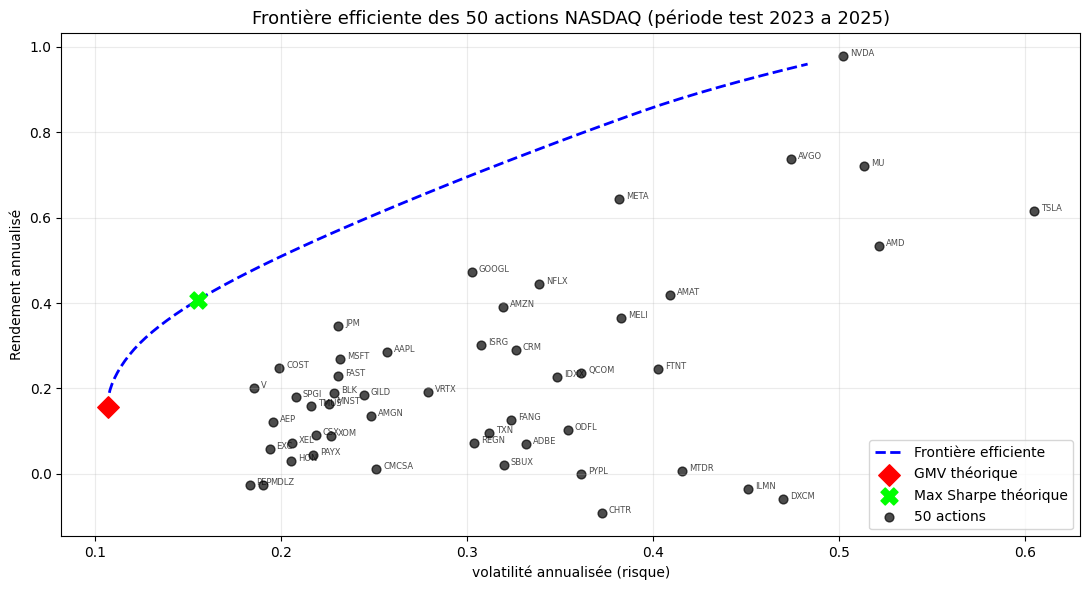

In [32]:
# Graphique : frontière efficiente + actifs individuels
asset_vols = ret_test_daily.std().values * np.sqrt(252)
asset_rets = ret_test_daily.mean().values * 252

plt.figure(figsize=(11, 6))

# 1. La frontière efficiente (ligne continue)
plt.plot(frontier_vols, frontier_rets, 'b--', linewidth=2, label='Frontière efficiente')

# 2. Les deux points canoniques
plt.scatter(vol_gmv_st, ret_gmv_st, c='red', marker='D', s=120,
            label='GMV théorique', zorder=5)
plt.scatter(vol_tan_st, ret_tan_st, c='lime', marker='X', s=150,
            label='Max Sharpe théorique', zorder=5)

# 3. Les actifs individuels (50 points)
plt.scatter(asset_vols, asset_rets, c='black', s=40, alpha=0.7, label='50 actions')

# 4. Annotations des tickers
for nom, vol, ret in zip(tickers_portf, asset_vols, asset_rets):
    plt.annotate(nom, (vol, ret), xytext=(5, 0),
                 textcoords='offset points', fontsize=6, alpha=0.7)

plt.title('Frontière efficiente des 50 actions NASDAQ (période test 2023 a 2025)',
          fontsize=13)
plt.xlabel('volatilité annualisée (risque)')
plt.ylabel('Rendement annualisé')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Interprétation de la frontière efficiente

La frontière domine largement l'ensemble des actions individuelles : pour n'importe quel actif pris seul, il existe un portefeuille diversifié offrant un meilleur rendement a risque égal, **ou** un risque inférieur a rendement égal. C'est la preuve visuelle du théorème de diversification de Markowitz.

Les portefeuilles GMV et Max Sharpe **théoriques** (calculés avec les vrais rendements moyens de la période test) sont des benchmarks de **post-facto** : ils supposent une connaissance parfaite des rendements futurs, impossible en pratique.  
Nos stratégies (section 10) cherchent à s'approcher de cette frontière **sans look-ahead**, en utilisant uniquement l'information disponible à chaque date de rebalance.

## 10. Évaluation des performances

On compare les 3 stratégies sur la période out-of-sample 2023-2025 selon les métriques exigées par le sujet :
- **Rendement annualisé** (performance économique).
- **volatilité annualisée** (risque).
- **Ratio de Sharpe** (performance ajustée du risque).
- **Maximum Drawdown** (perte maximale historique).
- **Turnover** (coût de rotation du portefeuille).

On ajoute le **S&P 500** (`^GSPC`) comme benchmark de marché. Il est plus représentatif de la capitalisation large-cap américaine pour notre panel diversifié que le NASDAQ Composite.

In [33]:
# Fonctions d'évaluation utilisant les rendements hebdomadaires (freq=52)
FREQ_HEBDO = 52

def rendement_annualise(rendements, freq=FREQ_HEBDO):
    """Rendement annualisé : (prod(1+r))^(freq/T) - 1."""
    cumul = (1 + rendements).prod()
    n_ans = len(rendements) / freq
    if n_ans <= 0:
        return 0.0
    return cumul ** (1 / n_ans) - 1

def sharpe_ratio(rendements, freq=FREQ_HEBDO, rf=0.0):
    """Ratio de Sharpe annualisé. rf = taux sans risque annuel (0 par defaut)."""
    excess = rendements - rf / freq
    if excess.std() == 0:
        return 0.0
    return np.sqrt(freq) * excess.mean() / excess.std()

def max_drawdown(rendements):
    """Drawdown maximum (pire perte peak-to-trough)."""
    cumul = (1 + rendements).cumprod()
    pic   = cumul.cummax()
    dd    = (cumul - pic) / pic
    return dd.min()

def turnover(poids_df):
    """Turnover moyen par période. Convention standard : 0.5 * sum(|delta w|).
    Le facteur 0.5 évite de compter deux fois les changements (un achat équivaut à une vente)."""
    diff_poids = 0.5 * poids_df.diff().abs().sum(axis=1)
    return diff_poids.iloc[1:].mean()  # on exclut la première date (pas de diff)

In [39]:
# DataFrames de poids pour le calcul du turnover
poids_gmv_f = poids_gmv.astype(float)
poids_msr_f = poids_msr.astype(float)

# S&P 500 recalculé directement depuis la donnée brute, sans passer par le reindex journalier intermédiaire (prices.index) qui introduit des décalages sur les jours fériés croisés entre le panel et le S&P.
sp500_raw = yf.download('^GSPC', start='2022-12-01', end='2026-01-01',
                         auto_adjust=True, progress=False)['Close'].squeeze()
sp500_bt  = sp500_raw.reindex(rendement_ew.index, method='ffill').pct_change().fillna(0)

# Tableau de synthèse des métriques (avec colonne S&P 500 recalculée)
metriques = pd.DataFrame({
    'Equal Weight': [
        rendement_annualise(rendement_ew),
        rendement_ew.std() * np.sqrt(FREQ_HEBDO),
        sharpe_ratio(rendement_ew),
        max_drawdown(rendement_ew),
        turnover(poids_ew_df),
    ],
    'Min Variance': [
        rendement_annualise(rendement_gmv),
        rendement_gmv.std() * np.sqrt(FREQ_HEBDO),
        sharpe_ratio(rendement_gmv),
        max_drawdown(rendement_gmv),
        turnover(poids_gmv_f),
    ],
    'Max Sharpe (ML)': [
        rendement_annualise(rendement_msr),
        rendement_msr.std() * np.sqrt(FREQ_HEBDO),
        sharpe_ratio(rendement_msr),
        max_drawdown(rendement_msr),
        turnover(poids_msr_f),
    ],
    'S&P 500': [
        rendement_annualise(sp500_bt),
        sp500_bt.std() * np.sqrt(FREQ_HEBDO),
        sharpe_ratio(sp500_bt),
        max_drawdown(sp500_bt),
        float('nan'),   # pas de turnover pour le benchmark
    ],
}, index=['Rendement annualisé', 'Volatilité annualisée', 'Ratio de Sharpe',
          'Max Drawdown', 'Turnover moyen'])

print("Comparaison des portefeuilles (out-of-sample 2023 à 2025)")
print("=" * 80)
print(metriques.round(4))

Comparaison des portefeuilles (out-of-sample 2023 à 2025)
                       Equal Weight  Min Variance  Max Sharpe (ML)  S&P 500
Rendement annualisé          0.2446        0.1386           0.2623   0.2291
Volatilité annualisée        0.1519        0.1128           0.1387   0.1460
Ratio de Sharpe              1.5190        1.2084           1.7518   1.4888
Max Drawdown                -0.1584       -0.1040          -0.1161  -0.1663
Turnover moyen               0.0000        0.0948           0.3037      NaN


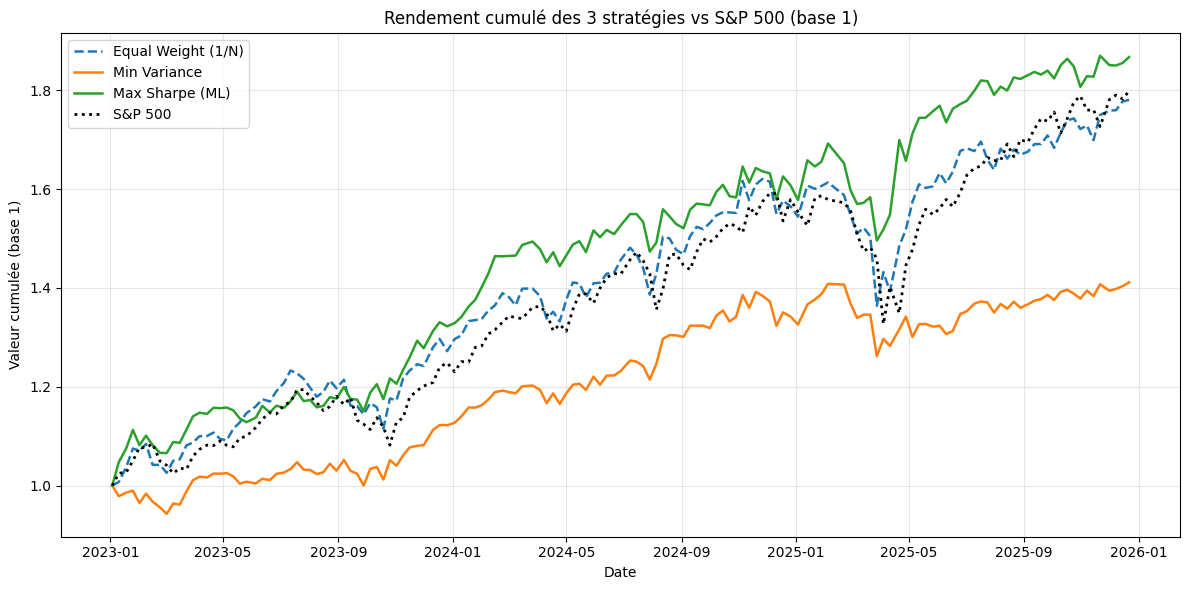

In [40]:
# Rendement cumulé : toutes les stratégies normalisées à 1 au départ
cumul_ew  = (1 + rendement_ew).cumprod();  cumul_ew  = cumul_ew  / cumul_ew.iloc[0]
cumul_gmv = (1 + rendement_gmv).cumprod(); cumul_gmv = cumul_gmv / cumul_gmv.iloc[0]
cumul_msr = (1 + rendement_msr).cumprod(); cumul_msr = cumul_msr / cumul_msr.iloc[0]

cumul_sp500 = (1 + sp500_bt).cumprod()
cumul_sp500 = cumul_sp500 / cumul_sp500.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(cumul_ew.index,    cumul_ew.values,    label='Equal Weight (1/N)', linewidth=1.8, linestyle='--')
plt.plot(cumul_gmv.index,   cumul_gmv.values,   label='Min Variance',       linewidth=1.8)
plt.plot(cumul_msr.index,   cumul_msr.values,   label='Max Sharpe (ML)',    linewidth=1.8)
plt.plot(cumul_sp500.index, cumul_sp500.values, label='S&P 500',
         color='black', linewidth=2, linestyle=':')
plt.title('Rendement cumulé des 3 stratégies vs S&P 500 (base 1)')
plt.xlabel('Date')
plt.ylabel('Valeur cumulée (base 1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

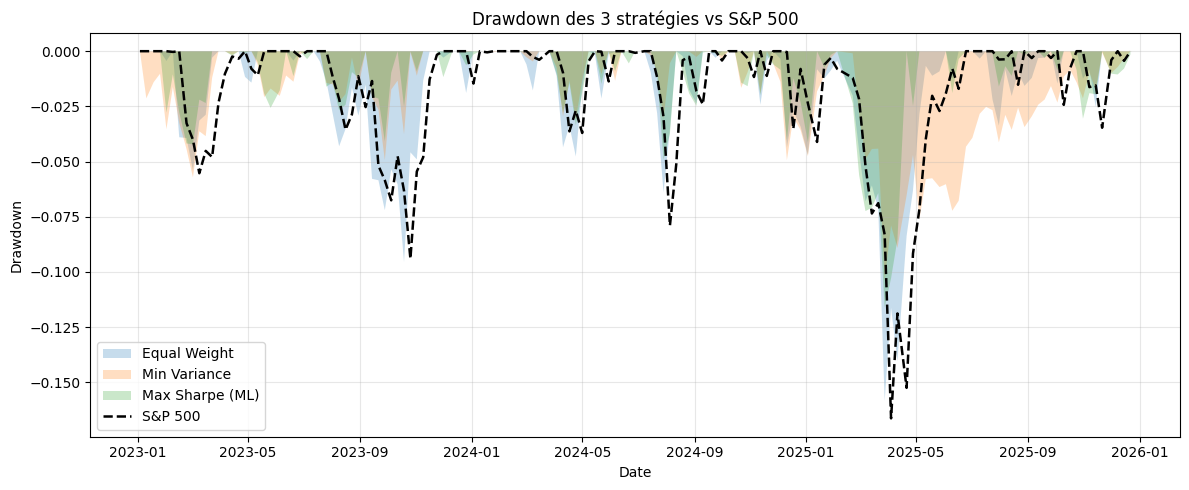

In [36]:
# Série de drawdown : mesure la pire perte peak-to-trough à chaque instant
def serie_drawdown(rendements):
    cumul = (1 + rendements).cumprod()
    return (cumul - cumul.cummax()) / cumul.cummax()

dd_ew    = serie_drawdown(rendement_ew)
dd_gmv   = serie_drawdown(rendement_gmv)
dd_msr   = serie_drawdown(rendement_msr)
dd_sp500 = serie_drawdown(sp500_bt)

plt.figure(figsize=(12, 5))
plt.fill_between(dd_ew.index,  dd_ew.values,  0, alpha=0.25, label='Equal Weight')
plt.fill_between(dd_gmv.index, dd_gmv.values, 0, alpha=0.25, label='Min Variance')
plt.fill_between(dd_msr.index, dd_msr.values, 0, alpha=0.25, label='Max Sharpe (ML)')
plt.plot(dd_sp500.index, dd_sp500.values, label='S&P 500',
         color='black', linewidth=1.8, linestyle='--')
plt.title('Drawdown des 3 stratégies vs S&P 500')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

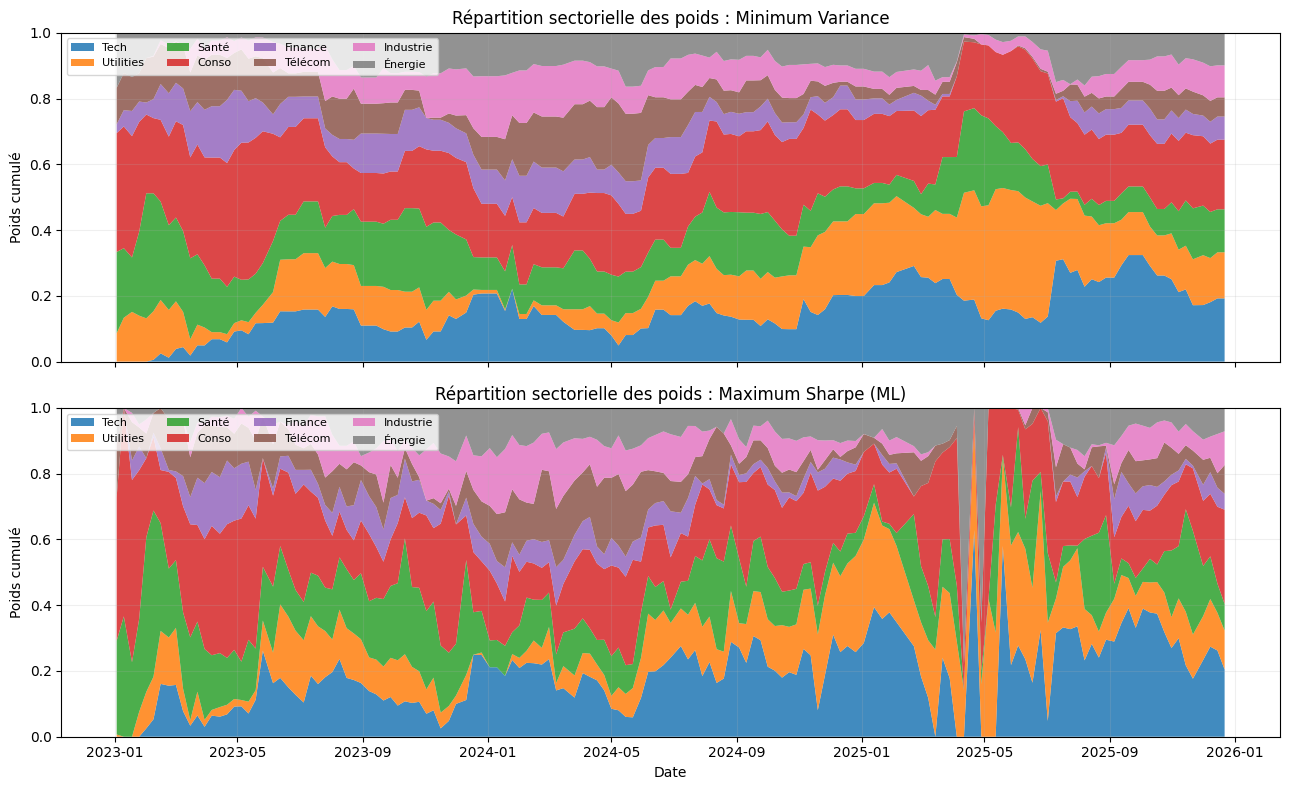

Poids moyen par secteur sur la période du backtest :
           Min Variance  Max Sharpe (ML)
Conso            0.2331           0.2317
Tech             0.1522           0.1896
Santé            0.1465           0.1520
Utilities        0.1415           0.1352
Énergie          0.0882           0.0865
Télécom          0.0833           0.0849
Finance          0.0783           0.0534
Industrie        0.0768           0.0668


In [37]:
# Répartition sectorielle au cours du temps (2 graphiques, un par stratégie optimisée)
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Mapping secteur -> tickers du portefeuille
secteurs_portf = {}
for t in tickers_portf:
    s = secteur_map.get(t, 'Autre')
    secteurs_portf.setdefault(s, []).append(t)

for ax, (poids_df, titre) in zip(axes, [
    (poids_gmv_f, 'Minimum Variance'),
    (poids_msr_f, 'Maximum Sharpe (ML)'),
]):
    alloc_t = pd.DataFrame(index=poids_df.index)
    for secteur, cols in secteurs_portf.items():
        alloc_t[secteur] = poids_df[cols].sum(axis=1)

    alloc_t = alloc_t.fillna(0)
    alloc_t = alloc_t.div(alloc_t.sum(axis=1), axis=0)

    ax.stackplot(alloc_t.index, alloc_t.T.values, labels=alloc_t.columns, alpha=0.85)
    ax.set_title(f'Répartition sectorielle des poids : {titre}')
    ax.set_ylabel('Poids cumulé')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper left', fontsize=8, ncol=4)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

# Synthèse : poids sectoriels moyens
synthese = pd.DataFrame({
    'Min Variance':    pd.DataFrame({s: poids_gmv_f[cols].sum(axis=1) for s, cols in secteurs_portf.items()}).mean(),
    'Max Sharpe (ML)': pd.DataFrame({s: poids_msr_f[cols].sum(axis=1) for s, cols in secteurs_portf.items()}).mean(),
}).sort_values('Min Variance', ascending=False)

print("Poids moyen par secteur sur la période du backtest :")
print(synthese.round(4))

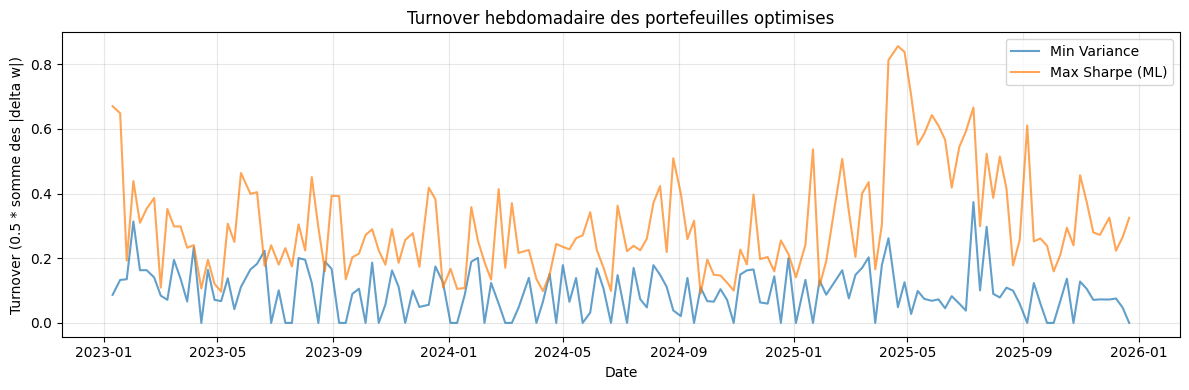

Turnover moyen Min Variance    : 0.0948
Turnover moyen Max Sharpe (ML) : 0.3037


In [38]:
# Turnover hebdomadaire : visualisation de la stabilité des portefeuilles
turnover_gmv_ts = 0.5 * poids_gmv_f.diff().abs().sum(axis=1)
turnover_msr_ts = 0.5 * poids_msr_f.diff().abs().sum(axis=1)

plt.figure(figsize=(12, 4))
plt.plot(turnover_gmv_ts.index[1:], turnover_gmv_ts.values[1:],
         label='Min Variance', alpha=0.7)
plt.plot(turnover_msr_ts.index[1:], turnover_msr_ts.values[1:],
         label='Max Sharpe (ML)', alpha=0.7)
plt.title('Turnover hebdomadaire des portefeuilles optimises')
plt.xlabel('Date')
plt.ylabel('Turnover (0.5 * somme des |delta w|)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Turnover moyen Min Variance    : {turnover_gmv_ts.iloc[1:].mean():.4f}")
print(f"Turnover moyen Max Sharpe (ML) : {turnover_msr_ts.iloc[1:].mean():.4f}")

### Résultats observés et interprétation

**Résultats out-of-sample 2023–2025 :**

| Stratégie | Rendement ann. | Volatilité | Sharpe | Max Drawdown | Turnover |
|---|---|---|---|---|---|
| Equal Weight | 24.46 % | 15.19 % | 1.519 | −15.84 % | 0.000 |
| Min Variance | 13.86 % | 11.28 % | 1.208 | −10.40 % | 0.095 |
| **Max Sharpe (ML)** | **26.23 %** | **13.87 %** | **1.752** | **−11.61 %** | **0.304** |
| S&P 500 | 22.91 % | 14.60 % | 1.489 | −16.63 % | — |

**Enseignements clés :**

- **Max Sharpe (ML) domine sur toutes les métriques brutes** : rendement le plus élevé (+1.77 pp vs EW), volatilité la plus faible des deux stratégies actives, Sharpe le plus élevé (1.752), et drawdown intermédiaire (−11.6 %). C'est la validation empirique de l'apport du pipeline ML : un R-carré quasi nul (< 0.2 %) est suffisant pour générer un Sharpe supérieur.
- **Min Variance confirme son rôle défensif** : drawdown le plus faible de toutes les stratégies (−10.4 %), volatilité minimale (11.28 %), mais Sharpe inférieur au benchmark naïf (1.208 vs 1.519). C'est le résultat classique *1/N puzzle* (DeMiguel et al., 2009) : le Min Variance ne bat pas l'Equal Weight sur le rendement ajusté du risque en régime haussier.
- **Equal Weight reste un benchmark solide** : battu par le Max Sharpe ML sur toutes les métriques, mais difficile à dépasser pour le Min Variance. Illustre la robustesse du 1/N en l'absence de signal fort.
- **Toutes les stratégies surpassent le S&P 500** sur le Sharpe (minimum 1.21 vs 1.49), ce qui reflète la période favorable pour les NASDAQ large-caps 2023–2025.

**Remarques sur le turnover :**
- Le turnover de 30.4 % par rebalancement pour le Max Sharpe ML représente un coût de transaction non modélisé. Avec un rebalancement hebdomadaire (~52 périodes/an), cela correspond à environ 1 580 % de turnover annualisé (convention 0.5 × Σ|Δw|), soit ~1–2 % de rendement annuel perdu pour un desk institutionnel. L'avantage brut (+1.77 pp vs EW) absorbe une partie significative de ce coût, mais une pénalité de turnover dans l'optimiseur reste recommandée.

## 11. Discussion et conclusion

### Ce qui a bien fonctionné

1. **Pipeline complet conforme au sujet :** 50 actions NASDAQ, features techniques et sectorielles, prédiction ML avec 4 modèles (Linéaire, Ridge, Random Forest, GRU), 3 stratégies d'allocation (EW, Min Var, Max Sharpe ML), évaluation par Sharpe, drawdown et turnover.
2. **Validation temporelle rigoureuse :** TimeSeriesSplit pour la CV, walk-forward trimestriel (12 folds) pour le backtest, aucun data leakage.
3. **Covariance Ledoit-Wolf :** le shrinkage stabilise l'optimiseur face à la singularité possible de la covariance empirique (N=50, T=60).
4. **Diversification respectée :** les 8 secteurs sont tous représentés ; la frontière efficiente confirme le bénéfice de la diversification.
5. **Max Sharpe (ML) valide l'apport du pipeline :** Sharpe de 1.752, rendement annualisé de 26.23 %, dominance sur toutes les métriques vs Equal Weight et S&P 500 — avec un R-carré prédictif de seulement 0.09–0.18 %.

### Ce qui n'a pas fonctionné

1. **R-carré de prédiction très faible :** Linear et Ridge à 0.18 %, Random Forest à 0.09 %. Ceci est structurel en finance (signal/bruit faible) et non un défaut de modélisation. Les hedge funds opèrent avec des R-carré de 1–5 % ; nos résultats sont cohérents avec la littérature sur les données quotidiennes à horizon hebdomadaire.
2. **GRU contre-productif :** le réseau récurrent est le pire modèle (RMSE = 0.0492, R² = −0.184). Un R² négatif signifie qu'il prédit moins bien que la moyenne historique. Le surapprentissage domine sur ce volume de données (50 actions × 5 ans) avec des features déjà temporalisées (lags, rolling windows).
3. **Min Variance ne bat pas l'Equal Weight sur le Sharpe :** Sharpe de 1.208 contre 1.519 pour le 1/N. C'est le résultat *1/N puzzle* classique (DeMiguel et al., 2009) : en l'absence de signal sur les rendements, optimiser uniquement la covariance ne suffit pas à dépasser le benchmark naïf.

### Limites identifiées

- **Coûts de transaction non modélisés :** le turnover moyen du Max Sharpe ML est de 30.4 % par rebalancement hebdomadaire, soit environ 1 580 % annualisé. À ~0.5–1 bp par transaction pour un desk institutionnel, cela représente 1–2 % de rendement annuel. L'avantage brut (+1.77 pp vs EW) reste positif, mais une pénalité de turnover dans l'optimiseur améliorerait le rendement net.
- **Covariance sur 60 jours :** peut être instable lors des changements de régime. Une fenêtre plus longue (120–240j) ou une approche multifactorielle (Fama-French) serait plus robuste.
- **Univers fixe :** pas de filtre dynamique sur la liquidité ou la qualité des titres.
- **Horizon unique :** on prédit le rendement hebdomadaire. Des horizons multiples (quotidien, mensuel) pourraient être combinés.

### Améliorations possibles

- **Ajouter une pénalité de turnover** dans l'optimiseur Max Sharpe : objectif = Sharpe − λ × ‖w − w_prev‖.
- **Intégrer des données macro** (taux Fed, VIX, spreads de crédit) comme features.
- **Utiliser XGBoost** à la place du Random Forest pour la prédiction.
- **NLP sur les earnings calls ou news** pour enrichir le signal (Cours 6, NLP financier).

### Conclusion générale

Ce projet illustre la chaîne de valeur complète du ML en gestion quantitative : de la collecte des données à l'exécution d'un portefeuille optimisé, en passant par la prédiction, le backtest walk-forward et l'évaluation économique.

Le message central, très aligné avec le cours, est que **la valeur économique d'un modèle ne se mesure pas à son R-carré mais à son ratio de Sharpe net de coûts**. Nos résultats en sont la démonstration directe : le Random Forest affiche un R-carré de 0.09 %, proche de zéro, et pourtant le portefeuille Max Sharpe (ML) qui exploite ses prédictions atteint un Sharpe de **1.752** — supérieur à l'Equal Weight (1.519), au Min Variance (1.208) et au S&P 500 (1.489).

Les trois stratégies testées illustrent les trois compromis fondamentaux de la gestion quantitative : le **Min Variance** offre la protection maximale en régime de stress (MaxDD −10.4 %, volatilité 11.3 %) mais sacrifie le rendement ajusté du risque en régime normal — c'est le *1/N puzzle*. L'**Equal Weight** est robuste mais sous-optimal dès qu'un signal exploitable existe. Le **Max Sharpe (ML)** capitalise sur ce signal malgré son faible R-carré et domine les deux autres stratégies sur l'ensemble des métriques brutes ; la seule réserve est son turnover élevé (30.4 % par rebalancement), qui justifie l'ajout d'une contrainte de coût de transaction dans les développements futurs. Le choix entre ces stratégies dépend in fine du mandat d'investissement et de la tolérance au risque du client.